In [9]:
# Install required libraries

!pip install xgboost shap joblib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# IMPORT LIBRARIES

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Model saving
import joblib

# SHAP explainability
import shap

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

c:\Users\Muskan Rathore\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# ================================
# LOAD FEATURE ENGINEERED DATASET
# ================================

df = pd.read_csv('output_day1\hr_attrition_feature_engineered.csv')


# Check first rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureBand,SalaryBand,tenure_risk_score,overtime_flag,salary_gap,manager_tenure_ratio
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,6,4,0,5,6-10 Years,3K-6K,0,1,-238.0,0.714286
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,10,7,1,7,6-10 Years,3K-6K,0,0,2242.5,0.636364
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,0,0,0,0,NaN,<3K,1,1,-796.0,0.000000
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,8,7,3,0,6-10 Years,<3K,0,1,21.5,0.000000
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,2,2,2,2,0-2 Years,3K-6K,0,0,582.0,0.666667


In [13]:
# CHECK DATASET

print(df.shape)

print(df.dtypes)

print(df.isnull().sum())

(1470, 41)
Age                           int64
Attrition                     int64
BusinessTravel                  str
DailyRate                     int64
Department                      str
DistanceFromHome              int64
Education                     int64
EducationField                  str
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                          str
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                         str
JobSatisfaction               int64
MaritalStatus                   str
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                          str
OverTime                        str
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours                 int64
StockOptionLevel 

In [14]:
# ENCODE CATEGORICAL VARIABLES

# Create label encoder
le = LabelEncoder()

# Find object columns
categorical_cols = df.select_dtypes(include='object').columns

# Encode all categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Check dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureBand,SalaryBand,tenure_risk_score,overtime_flag,salary_gap,manager_tenure_ratio
0,41,1,2,1102,2,1,2,1,1,1,...,6,4,0,5,3,1,0,1,-238.0,0.714286
1,49,0,1,279,1,8,1,1,1,2,...,10,7,1,7,3,1,0,0,2242.5,0.636364
2,37,1,2,1373,1,2,2,4,1,4,...,0,0,0,0,4,3,1,1,-796.0,0.000000
3,33,0,1,1392,1,3,4,1,1,5,...,8,7,3,0,3,3,0,1,21.5,0.000000
4,27,0,2,591,1,2,1,3,1,7,...,2,2,2,2,0,1,0,0,582.0,0.666667


In [15]:
# FEATURES & TARGET

# Features
X = df.drop('Attrition', axis=1)

# Target
y = df['Attrition']

In [16]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 40)
(294, 40)


In [17]:
# LOGISTIC REGRESSION MODEL

# Create model
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

# Train model
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Probability prediction
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Trained")

Logistic Regression Trained


In [18]:
# EVALUATE LOGISTIC REGRESSION

print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Precision:",
      precision_score(y_test, y_pred_log))

print("Recall:",
      recall_score(y_test, y_pred_log))

print("F1 Score:",
      f1_score(y_test, y_pred_log))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_log))

Accuracy: 0.6598639455782312
Precision: 0.27350427350427353
Recall: 0.6808510638297872
F1 Score: 0.3902439024390244
ROC-AUC: 0.7344301834783358


In [19]:
# RANDOM FOREST MODEL

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Trained")

Random Forest Trained


In [20]:
# EVALUATE RANDOM FOREST

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.826530612244898
Precision: 0.3333333333333333
Recall: 0.0851063829787234
F1 Score: 0.13559322033898305
ROC-AUC: 0.7692307692307692


In [21]:
# XGBOOST MODEL

# Create model
xgb_model = XGBClassifier(
    scale_pos_weight=5,
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost Trained")

XGBoost Trained


In [22]:
# EVALUATE XGBOOST

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("Precision:",
      precision_score(y_test, y_pred_xgb))

print("Recall:",
      recall_score(y_test, y_pred_xgb))

print("F1 Score:",
      f1_score(y_test, y_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.8605442176870748
Precision: 0.59375
Recall: 0.40425531914893614
F1 Score: 0.4810126582278481
ROC-AUC: 0.7640623654061504


In [23]:
# MODEL COMPARISON TABLE
comparison_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(comparison_df)

                 Model  Accuracy    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.659864  0.680851  0.390244  0.734430
1        Random Forest  0.826531  0.085106  0.135593  0.769231
2              XGBoost  0.860544  0.404255  0.481013  0.764062


In [24]:
# SELECT BEST MODEL

best_model = log_model

print("Best Model Selected: Logistic Regression")

Best Model Selected: Logistic Regression


In [25]:
# SAVE MODEL

import os

# Create models folder
os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(
    best_model,
    "models/best_attrition_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [26]:
# SHAP EXPLAINER

explainer = shap.LinearExplainer(
    best_model,
    X_train
)

shap_values = explainer.shap_values(X_test)

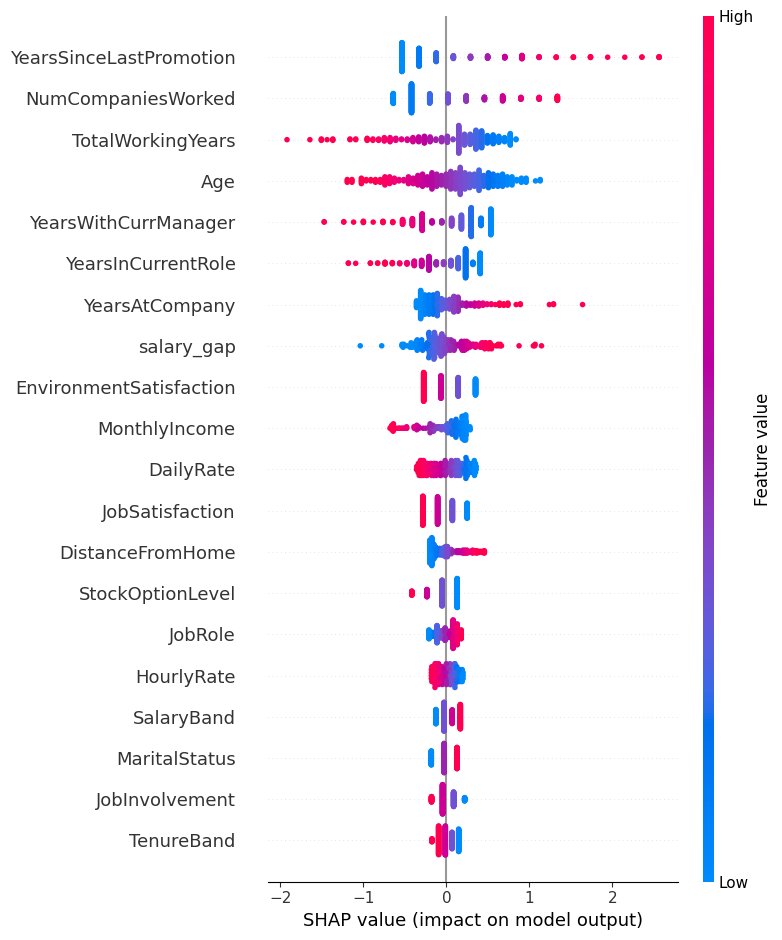

In [27]:
# SHAP SUMMARY PLOT

shap.summary_plot(
    shap_values,
    X_test
)

In [29]:
# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': abs(best_model.coef_[0])

})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                    Feature  Importance
19       NumCompaniesWorked    0.219773
9   EnvironmentSatisfaction    0.208297
32  YearsSinceLastPromotion    0.206636
21                 OverTime    0.182929
37            overtime_flag    0.182929
26         StockOptionLevel    0.182411
15          JobSatisfaction    0.177845
16            MaritalStatus    0.155043
12           JobInvolvement    0.133157
33     YearsWithCurrManager    0.118180


In [30]:
# COST OF ATTRITION

# Recruitment Cost
df['RecruitmentCost'] = (
    df['MonthlyIncome'] * 1
)

# Training Cost
df['TrainingCost'] = (
    df['MonthlyIncome'] * 2
)

# Productivity Loss
df['ProductivityLoss'] = (
    df['MonthlyIncome'] * 3 * 0.5
)

# Total Attrition Cost
df['TotalAttritionCost'] = (
    df['RecruitmentCost']
    + df['TrainingCost']
    + df['ProductivityLoss']
)

In [31]:
# ATTRITION COST BY JOB ROLE

cost_by_role = df.groupby(
    'JobRole'
)['TotalAttritionCost'].sum()

print(cost_by_role.sort_values(ascending=False))

JobRole
7    10157917.5
3     7886389.5
5     5772078.0
4     4760077.5
0     4438206.0
6     4257324.0
2     3772921.5
1      991165.5
8      980811.0
Name: TotalAttritionCost, dtype: float64


In [32]:
# 12 MONTH ATTRITION COST

# Current attrition rate
attrition_rate = df['Attrition'].mean()

# Total annual projected cost
projected_cost = (
    df['TotalAttritionCost'].sum()
    * attrition_rate
)

print("Projected 12-Month Attrition Cost:")
print(projected_cost)

Projected 12-Month Attrition Cost:
6935376.223469388


In [34]:
# EXPORT RESULTS

# Create output folder
os.makedirs("outputs", exist_ok=True)

# Save comparison table
comparison_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

# Save feature importance
feature_importance.to_csv(
    "outputs/feature_importance.csv",
    index=False
)

# Save cost model
df.to_csv(
    "outputs/hr_attrition_cost_model.csv",
    index=False
)

print("All Outputs Saved")

All Outputs Saved
